In [34]:
import sys
import os
path = os.path.dirname(os.path.abspath("."))
sys.path.append(path) # 将上级路径填入sys.path, 方便后面导入包

In [35]:
from models.table_models import *
from models.api import *
import pendulum
import backtrader as bt
import pandas as pd
import datetime

In [47]:
index_daily = data_api.Daily(ts_code='600601.SH')

In [48]:
index_daily

,ts_code_trade_date,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,600601.SH1990-12-19 00:00:00,600601.SH,1990-12-19,185.30,185.30,185.30,185.30,1.00,184.30,18430.0000,50.00,37.000
1,600601.SH1990-12-20 00:00:00,600601.SH,1990-12-20,185.30,194.60,185.30,194.60,185.30,9.30,5.0200,21.00,16.000
2,600601.SH1990-12-21 00:00:00,600601.SH,1990-12-21,204.30,204.30,204.30,204.30,194.60,9.70,4.9800,8.00,6.000
3,600601.SH1990-12-24 00:00:00,600601.SH,1990-12-24,214.60,214.60,214.50,214.50,204.30,10.20,4.9900,1.00,2.000
4,600601.SH1990-12-26 00:00:00,600601.SH,1990-12-26,236.50,236.50,236.50,236.50,214.50,22.00,10.2600,2.00,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...
7772,600601.SH2023-07-25 00:00:00,600601.SH,2023-07-25,3.72,3.84,3.66,3.77,3.69,0.08,2.1680,949309.04,356361.129
7773,600601.SH2023-07-26 00:00:00,600601.SH,2023-07-26,3.76,3.76,3.61,3.64,3.77,-0.13,-3.4483,641845.59,235452.689
7774,600601.SH2023-07-27 00:00:00,600601.SH,2023-07-27,3.59,3.66,3.50,3.52,3.64,-0.12,-3.2967,1038404.03,371228.892
7775,600601.SH2023-07-28 00:00:00,600601.SH,2023-07-28,3.53,3.61,3.49,3.60,3.52,0.08,2.2727,748510.14,266381.675


In [49]:
index_daily.rename(mapper={'vol':'volume', 'trade_date':'datetime'}, axis=1, inplace=True)
index_daily['openinterest'] = 0

In [50]:
index_daily = index_daily[['datetime', 'open', 'high', 'low', 'close', 'volume', 'openinterest']]
index_daily = index_daily.set_index('datetime')

In [51]:
# 缺失值处理：日期对齐时会使得有些交易日的数据为空，所以需要对缺失数据进行填充
index_daily.loc[:, ['volume', 'openinterest']] = index_daily.loc[:, ['volume', 'openinterest']].fillna(0)
index_daily.loc[:, ['open', 'high', 'low', 'close']] = index_daily.loc[:, ['open', 'high', 'low', 'close']].fillna(method='pad')
index_daily.loc[:, ['open', 'high', 'low', 'close']] = index_daily.loc[:, ['open', 'high', 'low', 'close']].fillna(0)

In [55]:
datafeed = bt.feeds.PandasData(dataname=index_daily, fromdate=datetime.datetime(2021, 12, 19),
                                   todate=datetime.datetime(2023, 4, 20))

In [56]:
class TestStrategy(bt.Strategy):
    """选股策略"""

    def next(self):
        dt = self.datas[0].datetime.date(0)
        dt = pendulum.parse(str(dt))
        if dt == dt.start_of('month'):
#             print(dt,dt.start_of('month'))
            order = self.order_target_percent(data=self.data, target= 0.95)  # 为减少可用资金不足的情况

<IPython.core.display.Javascript object>


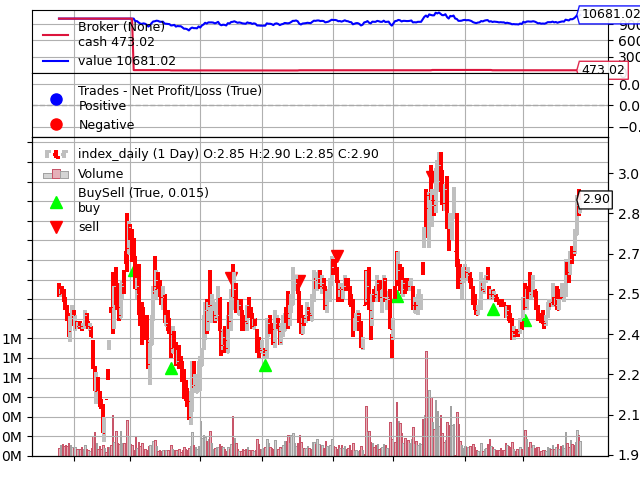

[[<Figure size 640x480 with 4 Axes>]]

In [57]:
# 实例化
cerebro = bt.Cerebro()
cerebro.addstrategy(TestStrategy)
cerebro.adddata(datafeed, name='index_daily')
cerebro.run()
cerebro.plot(style='bar')

In [113]:
class TestStrategy(bt.Strategy):
    """选股策略"""

    def next(self):
        
        order = self.order_target_percent(data=self.data, target= 1)  # 为减少可用资金不足的情况

-------------- AnnualReturn -----------------
OrderedDict([(1990, 0.0), (1991, 1.1789403539999999), (1992, 1.6650486064658936), (1993, 0.06842976319674632), (1994, -0.2229594840963799), (1995, -0.14287294403451856), (1996, 0.651282997242419), (1997, 0.3021186619669465), (1998, -0.03969284303936049), (1999, 0.19173045529044552), (2000, 0.517229725065828), (2001, -0.20616655255847993), (2002, -0.1751527060193574), (2003, 0.10266080491751373), (2004, -0.15398998212758164), (2005, -0.083244755518598), (2006, 1.304210453486209), (2007, 0.9665482195316886), (2008, -0.6539274779423674), (2009, 0.7997777711370948), (2010, -0.14312638684611112), (2011, -0.2167441823278029), (2012, 0.0316935123248554), (2013, -0.06748936779917958), (2014, 0.5286616614029105), (2015, 0.0941342400998928), (2016, -0.12305954842511313), (2017, 0.06557694111596635), (2018, -0.24590398633382005), (2019, 0.223025084234574), (2020, 0.1386595734494005), (2021, 0.04799801159512018), (2022, -0.15124548716727726), (2023, 0.

<IPython.core.display.Javascript object>


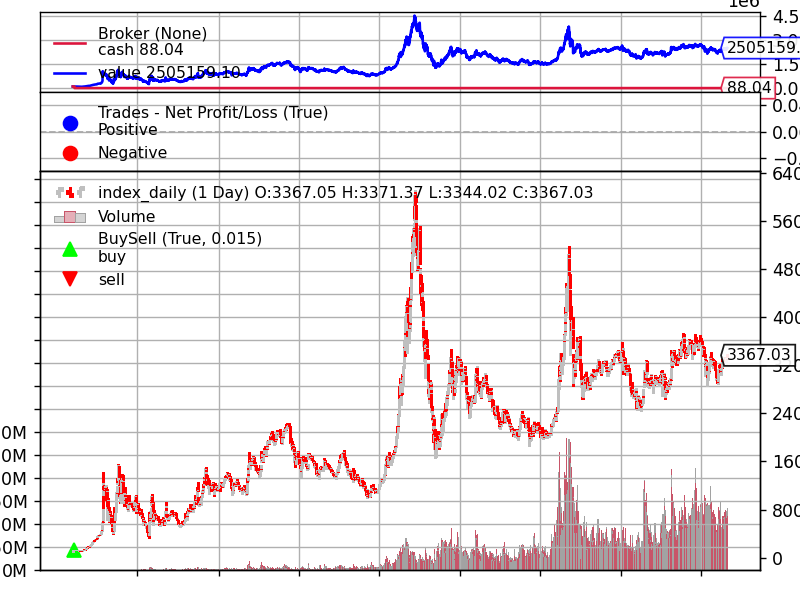

[[<Figure size 640x480 with 4 Axes>]]

In [114]:
# 实例化
cerebro = bt.Cerebro()
cerebro.adddata(datafeed, name='index_daily')

# 初始资金 100,000,000

cerebro.broker.setcash(100000.0)
# # 佣金，双边各0.0003
# cerebro.broker.setcommission(commission=0.0003)
# # 滑点：双边各 0.0001
# cerebro.broker.set_slippage_perc(perc=0.005)

cerebro.addanalyzer(bt.analyzers.TimeReturn, _name='pnl')  # 返回收益率时序数据
cerebro.addanalyzer(bt.analyzers.AnnualReturn, _name='_AnnualReturn')  # 年化收益率
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='_SharpeRatio')  # 夏普比率
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='_DrawDown')  # 回撤

# 将编写的策略添加给大脑
cerebro.addstrategy(TestStrategy, printlog=True)

# 启动回测
result = cerebro.run()
# 从返回的result中提取回测结果
strat = result[0]
# 返回日度收益率序列
daily_return = pd.Series(strat.analyzers.pnl.get_analysis())
# 打印评价指标
print('-------------- AnnualReturn -----------------')
print(strat.analyzers._AnnualReturn.get_analysis())
print('-------------- SharpeRatio ------------------')
print(strat.analyzers._SharpeRatio.get_analysis())
print('-------------- DrawDown ---------------------')
print(strat.analyzers._DrawDown.get_analysis())
cerebro.plot()